<a href="https://colab.research.google.com/github/alfarisauliarahman/BigData26_A_2411533006_AlfarisAuliaRahman/blob/main/Praktikum01/BD_A_P01_2411533006_AlfarisAuliaRahman.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Tutorial dan Langkah Kerja

1. Verifikasi lingkungan kerja

In [1]:
import sys, platform, multiprocessing

print("Python  :", sys.version.split()[0])
print("OS      :", platform.platform())
print("CPU core:", multiprocessing.cpu_count())

for nama in ["pandas", "numpy", "pyarrow", "matplotlib"]:
    try:
        mod = __import__(nama)
        print(f"{nama:11s}: {mod.__version__}")
    except ImportError:
        print(f"{nama:11s}: BELUM TERPASANG")

Python  : 3.13.15
OS      : Linux-6.6.122+-x86_64-with-glibc2.39
CPU core: 2
pandas     : 2.2.3
numpy      : 2.1.3
pyarrow    : 23.0.1
matplotlib : 3.10.0


In [2]:
!free -h        # kapasitas dan sisa RAM
!df -h /content # kapasitas dan sisa disk runtime
!java -version  # dibutuhkan PySpark pada langkah K-8

               total        used        free      shared  buff/cache   available
Mem:            12Gi       943Mi       8.9Gi       2.1Mi       3.1Gi        11Gi
Swap:             0B          0B          0B
Filesystem      Size  Used Avail Use% Mounted on
overlay         108G   21G   88G  19% /
[0.035s][warning][os,container] Cgroup memory controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
[0.035s][warning][os,container] Cgroup cpu controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
openjdk version "21.0.12" 2026-07-21
OpenJDK Runtime Environment (build 21.0.12+8-1-24.04-Ubuntu)
OpenJDK 64-Bit Server VM (build 21.0.12+8-1-24.04-Ubuntu, mixed mode, sharing)


2. Menghubungkan Google Drive dan menyiapkan struktur folder

In [3]:
from google.colab import drive
drive.mount("/content/drive")

import os
DIR_KERJA = "/content/data"
DIR_SIMPAN = "/content/drive/MyDrive/BigData/Praktikum1"
os.makedirs(DIR_KERJA, exist_ok=True)
os.makedirs(DIR_SIMPAN, exist_ok=True)
print(os.listdir(DIR_SIMPAN))

Mounted at /content/drive
['yellow_tripdata_2023-01.parquet', 'yellow_tripdata_2023-07.parquet', 'bersih_snappy.parquet', 'bersih_gzip.parquet', 'agregasi_per_jam.csv', 'agregasi_per_jam.parquet', 'distribusi_per_jam.png', 'pengukuran_kinerja.csv', 'studi_kasus_ringkas.csv', 'studi_kasus_sibuk_vs_lain.csv', 'studi_kasus_permintaan_per_jam.png', 'studi_kasus_perbandingan_hari.csv', 'studi_kasus_tarif_per_menit.png']


3. Menyiapkan alat ukur waktu dan memori

In [4]:
import time, os, psutil

proses = psutil.Process(os.getpid())
catatan = []

def rss_mb():
    return proses.memory_info().rss / 1024**2

def ukur(label, fungsi):
    """Menjalankan fungsi tanpa argumen, mencatat durasi dan pertumbuhan memori."""
    m0, t0 = rss_mb(), time.perf_counter()
    hasil = fungsi()
    detik = time.perf_counter() - t0
    delta = rss_mb() - m0
    catatan.append({"langkah": label, "detik": round(detik, 2),
                     "delta_rss_mb": round(delta, 1)})
    print(f"[{label}] {detik:.2f} s | RSS {delta:+.1f} MB")
    return hasil

4. Mengunduh dataset dan inspeksi awal

In [5]:
import urllib.request

URL = ("https://d37ci6vzurychx.cloudfront.net/trip-data/"
       "yellow_tripdata_2023-01.parquet")
PATH = os.path.join(DIR_KERJA, "yellow_tripdata_2023-01.parquet")

if not os.path.exists(PATH):
    ukur("unduh dataset", lambda: urllib.request.urlretrieve(URL, PATH))

print("Ukuran file:", round(os.path.getsize(PATH) / 1024**2, 1), "MB")

[unduh dataset] 0.48 s | RSS +1.8 MB
Ukuran file: 45.5 MB


In [6]:
import pyarrow.parquet as pq

meta = pq.ParquetFile(PATH).metadata
print("Jumlah baris  :", f"{meta.num_rows:,}")
print("Jumlah kolom  :", meta.num_columns)
print("Row group     :", meta.num_row_groups)
print("Nama kolom    :", pq.ParquetFile(PATH).schema.names)

Jumlah baris  : 3,066,766
Jumlah kolom  : 19
Row group     : 1
Nama kolom    : ['VendorID', 'tpep_pickup_datetime', 'tpep_dropoff_datetime', 'passenger_count', 'trip_distance', 'RatecodeID', 'store_and_fwd_flag', 'PULocationID', 'DOLocationID', 'payment_type', 'fare_amount', 'extra', 'mta_tax', 'tip_amount', 'tolls_amount', 'improvement_surcharge', 'total_amount', 'congestion_surcharge', 'airport_fee']


5. Memuat data dan mengukur biaya memorinya

In [7]:
import pandas as pd

KOLOM = ["tpep_pickup_datetime", "tpep_dropoff_datetime",
         "passenger_count", "trip_distance", "payment_type",
         "fare_amount", "tip_amount", "total_amount"]

penuh = ukur("baca semua kolom", lambda: pd.read_parquet(PATH))
print("Dimensi:", penuh.shape)
print("Memori :", round(penuh.memory_usage(deep=True).sum() / 1024**2, 1), "MB")

del penuh                # bebaskan memori sebelum percobaan kedua
import gc; gc.collect()

df = ukur("baca kolom terpilih", lambda: pd.read_parquet(PATH, columns=KOLOM))
print("Dimensi:", df.shape)
print("Memori :", round(df.memory_usage(deep=True).sum() / 1024**2, 1), "MB")
df.head()

[baca semua kolom] 2.62 s | RSS +495.4 MB
Dimensi: (3066766, 19)
Memori : 565.6 MB
[baca kolom terpilih] 2.32 s | RSS +228.7 MB
Dimensi: (3066766, 8)
Memori : 187.2 MB


,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,payment_type,fare_amount,tip_amount,total_amount
0,2023-01-01 00:32:10,2023-01-01 00:40:36,1.0,0.97,2,9.3,0.00,14.30
1,2023-01-01 00:55:08,2023-01-01 01:01:27,1.0,1.10,1,7.9,4.00,16.90
2,2023-01-01 00:25:04,2023-01-01 00:37:49,1.0,2.51,1,14.9,15.00,34.90
3,2023-01-01 00:03:48,2023-01-01 00:13:25,0.0,1.90,1,12.1,0.00,20.85
4,2023-01-01 00:10:29,2023-01-01 00:21:19,1.0,1.43,1,11.4,3.28,19.68


In [8]:
df.info(memory_usage="deep")
df.memory_usage(deep=True).sort_values(ascending=False) / 1024**2    # MB per kolom

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3066766 entries, 0 to 3066765
Data columns (total 8 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   tpep_pickup_datetime   datetime64[us]
 1   tpep_dropoff_datetime  datetime64[us]
 2   passenger_count        float64       
 3   trip_distance          float64       
 4   payment_type           int64         
 5   fare_amount            float64       
 6   tip_amount             float64       
 7   total_amount           float64       
dtypes: datetime64[us](2), float64(5), int64(1)
memory usage: 187.2 MB


,0
tpep_pickup_datetime,23.397568
payment_type,23.397568
tpep_dropoff_datetime,23.397568
passenger_count,23.397568
trip_distance,23.397568
tip_amount,23.397568
fare_amount,23.397568
total_amount,23.397568
Index,0.000126


In [9]:
sebelum = df.memory_usage(deep=True).sum() / 1024**2

df["passenger_count"] = pd.to_numeric(df["passenger_count"], downcast="float")
df["payment_type"]    = df["payment_type"].astype("int8").astype("category")
for kol in ["trip_distance", "fare_amount", "tip_amount", "total_amount"]:
    df[kol] = pd.to_numeric(df[kol], downcast="float")

sesudah = df.memory_usage(deep=True).sum() / 1024**2
print(f"{sebelum:.1f} MB -> {sesudah:.1f} MB  (hemat {100*(1-sesudah/sebelum):.1f}%)")
df.dtypes

187.2 MB -> 119.9 MB  (hemat 35.9%)


,0
tpep_pickup_datetime,datetime64[us]
tpep_dropoff_datetime,datetime64[us]
passenger_count,float32
trip_distance,float64
payment_type,category
fare_amount,float32
tip_amount,float32
total_amount,float32


6. Pemeriksaan kualitas data dan pembersihan (veracity)

In [10]:
df["durasi_menit"] = (df["tpep_dropoff_datetime"] -
                      df["tpep_pickup_datetime"]).dt.total_seconds() / 60

print(df[["trip_distance", "durasi_menit", "total_amount"]].describe())
print("\nNilai kosong per kolom:\n", df.isna().sum())

anomali = {
    "jarak <= 0"        : (df["trip_distance"] <= 0).sum(),
    "durasi <= 0"       : (df["durasi_menit"] <= 0).sum(),
    "durasi > 180 menit": (df["durasi_menit"] > 180).sum(),
    "total_amount <= 0" : (df["total_amount"] <= 0).sum(),
}
for k, v in anomali.items():
    print(f"{k:22s}: {v:,} baris ({100*v/len(df):.2f}%)")

       trip_distance  durasi_menit  total_amount
count   3.066766e+06  3.066766e+06  3.066766e+06
mean    3.847342e+00  1.566900e+01  2.702038e+01
std     2.495838e+02  4.259435e+01  2.212666e+01
min     0.000000e+00 -2.920000e+01 -7.510000e+02
25%     1.060000e+00  7.116667e+00  1.540000e+01
50%     1.800000e+00  1.151667e+01  2.016000e+01
75%     3.330000e+00  1.830000e+01  2.870000e+01
max     2.589281e+05  1.002918e+04  1.169400e+03

Nilai kosong per kolom:
 tpep_pickup_datetime         0
tpep_dropoff_datetime        0
passenger_count          71743
trip_distance                0
payment_type                 0
fare_amount                  0
tip_amount                   0
total_amount                 0
durasi_menit                 0
dtype: int64
jarak <= 0            : 45,862 baris (1.50%)
durasi <= 0           : 1,121 baris (0.04%)
durasi > 180 menit    : 3,048 baris (0.10%)
total_amount <= 0     : 25,772 baris (0.84%)


In [11]:
layak = (
    (df["trip_distance"] > 0) & (df["trip_distance"] < 100) &
    df["durasi_menit"].between(1, 180) &
    (df["total_amount"] > 0)
)
bersih = df.loc[layak].copy()
print(f"{len(df):,} baris -> {len(bersih):,} baris (dibuang {len(df)-len(bersih):,})")

3,066,766 baris -> 2,986,911 baris (dibuang 79,855)


7. Memproses file lebih besar dari memori dengan chunking

In [12]:
CSV = os.path.join(DIR_KERJA, "trips.csv")
ukur("tulis CSV", lambda: bersih.to_csv(CSV, index=False))

print("Parquet:", round(os.path.getsize(PATH) / 1024**2, 1), "MB")
print("CSV    :", round(os.path.getsize(CSV) / 1024**2, 1), "MB")

[tulis CSV] 48.09 s | RSS +5.9 MB
Parquet: 45.5 MB
CSV    : 226.2 MB


In [13]:
def agregasi_bertahap(path, ukuran_chunk=500_000):
    jumlah_baris = 0
    total_nilai  = 0.0
    per_jam      = {}
    potongan = pd.read_csv(
        path,
        usecols=["tpep_pickup_datetime", "total_amount"],
        parse_dates=["tpep_pickup_datetime"],
        chunksize=ukuran_chunk)
    for chunk in potongan:
        jumlah_baris += len(chunk)
        total_nilai += chunk["total_amount"].sum()
        for jam, sub in chunk.groupby(chunk["tpep_pickup_datetime"].dt.hour):
            n, nilai = per_jam.get(jam, (0, 0.0))
            per_jam[jam] = (n + len(sub), nilai + sub["total_amount"].sum())
    return jumlah_baris, total_nilai, per_jam

baris, total, per_jam_chunk = ukur(
    "agregasi chunking", lambda: agregasi_bertahap(CSV))
print(f"{baris:,} baris | rata-rata total_amount = {total/baris:.2f}")

[agregasi chunking] 4.26 s | RSS +19.4 MB
2,986,911 baris | rata-rata total_amount = 27.33


8. Pendekatan terdistribusi: PySpark local mode

In [32]:
!pip install -q pyspark==3.5.1
!java -version

[0.001s][warning][os,container] Cgroup memory controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
[0.001s][warning][os,container] Cgroup cpu controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
openjdk version "21.0.12" 2026-07-21
OpenJDK Runtime Environment (build 21.0.12+8-1-24.04-Ubuntu)
OpenJDK 64-Bit Server VM (build 21.0.12+8-1-24.04-Ubuntu, mixed mode, sharing)


In [15]:
from pyspark.sql import SparkSession, functions as F

spark = (SparkSession.builder
         .appName("BD-P01")
         .master("local[*]")                     # semua core mesin ini
         .config("spark.driver.memory", "4g")
         .config("spark.sql.shuffle.partitions", "8")
         .getOrCreate())
spark.sparkContext.setLogLevel("WARN")
print("Spark:", spark.version)

Spark: 3.5.1


In [16]:
sdf = spark.read.parquet(PATH)
sdf.printSchema()
print("Jumlah baris:", ukur("spark count", lambda: sdf.count()))

sdf_bersih = (sdf
    .withColumn(
        "durasi_menit",
        (F.unix_timestamp("tpep_dropoff_datetime")
         - F.unix_timestamp("tpep_pickup_datetime")) / 60)
    .filter((F.col("trip_distance") > 0) & (F.col("trip_distance") < 100))
    .filter((F.col("durasi_menit") >= 1) & (F.col("durasi_menit") <= 180))
    .filter(F.col("total_amount") > 0))

hasil_spark = (sdf_bersih
    .withColumn("jam", F.hour("tpep_pickup_datetime"))
    .groupBy("jam")
    .agg(F.count("*").alias("jumlah"),
         F.round(F.avg("trip_distance"), 2).alias("rata_jarak"),
         F.round(F.avg("total_amount"), 2).alias("rata_tarif"))
    .orderBy("jam"))

ukur("Spark agregasi", lambda: hasil_spark.show(24, truncate=False))

root
 |-- VendorID: long (nullable = true)
 |-- tpep_pickup_datetime: timestamp_ntz (nullable = true)
 |-- tpep_dropoff_datetime: timestamp_ntz (nullable = true)
 |-- passenger_count: double (nullable = true)
 |-- trip_distance: double (nullable = true)
 |-- RatecodeID: double (nullable = true)
 |-- store_and_fwd_flag: string (nullable = true)
 |-- PULocationID: long (nullable = true)
 |-- DOLocationID: long (nullable = true)
 |-- payment_type: long (nullable = true)
 |-- fare_amount: double (nullable = true)
 |-- extra: double (nullable = true)
 |-- mta_tax: double (nullable = true)
 |-- tip_amount: double (nullable = true)
 |-- tolls_amount: double (nullable = true)
 |-- improvement_surcharge: double (nullable = true)
 |-- total_amount: double (nullable = true)
 |-- congestion_surcharge: double (nullable = true)
 |-- airport_fee: double (nullable = true)

[spark count] 9.23 s | RSS +0.0 MB
Jumlah baris: 3066766
+---+------+----------+----------+
|jam|jumlah|rata_jarak|rata_tarif|
+--

In [17]:
sdf_bersih.createOrReplaceTempView("trips")
spark.sql("""
    SELECT payment_type,
           COUNT(*)                  AS jumlah,
           ROUND(AVG(total_amount), 2) AS rata_tarif,
           ROUND(AVG(tip_amount), 2)   AS rata_tip
    FROM trips
    GROUP BY payment_type
    ORDER BY jumlah DESC
""").show()

hasil_spark.explain()       # rencana eksekusi - perhatikan Exchange/HashAggregate
spark.stop()                # bebaskan sumber daya sebelum lanjut

+------------+-------+----------+--------+
|payment_type| jumlah|rata_tarif|rata_tip|
+------------+-------+----------+--------+
|           1|2385064|      28.1|    4.16|
|           2| 512987|     23.58|     0.0|
|           0|  64106|     29.82|    4.06|
|           4|  15570|     24.11|    0.02|
|           3|   9184|     22.63|     0.0|
+------------+-------+----------+--------+

== Physical Plan ==
AdaptiveSparkPlan isFinalPlan=false
+- Sort [jam#84 ASC NULLS FIRST], true, 0
   +- Exchange rangepartitioning(jam#84 ASC NULLS FIRST, 8), ENSURE_REQUIREMENTS, [plan_id=206]
      +- HashAggregate(keys=[jam#84], functions=[count(1), avg(trip_distance#4), avg(total_amount#16)])
         +- Exchange hashpartitioning(jam#84, 8), ENSURE_REQUIREMENTS, [plan_id=203]
            +- HashAggregate(keys=[jam#84], functions=[partial_count(1), partial_avg(trip_distance#4), partial_avg(total_amount#16)])
               +- Project [trip_distance#4, total_amount#16, hour(tpep_pickup_datetime#1, Some(

9. Agregasi akhir dengan pandas dan penyimpanan artefak

In [18]:
bersih["jam"] = bersih["tpep_pickup_datetime"].dt.hour

agregasi = (bersih
    .groupby("jam")
    .agg(jumlah_perjalanan=("total_amount", "size"),
         rata_jarak=("trip_distance", "mean"),
         rata_durasi=("durasi_menit", "mean"),
         rata_tarif=("total_amount", "mean"),
         median_tarif=("total_amount", "median"))
    .round(2)
    .reset_index())

agregasi.to_csv(f"{DIR_SIMPAN}/agregasi_per_jam.csv", index=False)
agregasi.to_parquet(f"{DIR_SIMPAN}/agregasi_per_jam.parquet", index=False)
pd.DataFrame(catatan).to_csv(f"{DIR_SIMPAN}/pengukuran_kinerja.csv", index=False)

agregasi

,jam,jumlah_perjalanan,rata_jarak,rata_durasi,rata_tarif,median_tarif
0,0,82289,4.04,13.57,28.860001,21.600000
1,1,57766,3.53,12.63,26.450001,21.200001
2,2,40445,3.28,12.07,25.059999,20.520000
3,3,26146,3.58,12.15,26.260000,21.000000
4,4,16618,4.79,13.52,31.719999,22.700001
5,5,16940,6.03,14.70,36.750000,22.040001
6,6,42300,4.80,14.49,30.629999,18.480000
7,7,84569,3.69,14.42,26.889999,18.480000
8,8,114064,3.08,14.33,25.209999,19.100000
9,9,127988,3.09,14.23,25.510000,19.250000


10. Visualisasi hasil

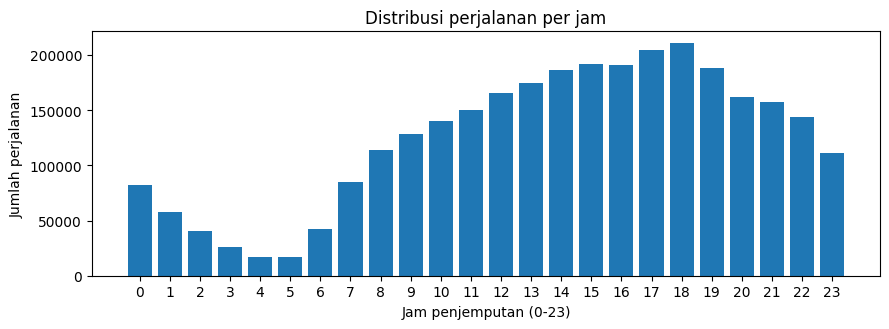

In [19]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(9, 3.4))
ax.bar(agregasi["jam"], agregasi["jumlah_perjalanan"])
ax.set_xlabel("Jam penjemputan (0-23)")
ax.set_ylabel("Jumlah perjalanan")
ax.set_title("Distribusi perjalanan per jam")
ax.set_xticks(range(0, 24))
fig.tight_layout()
fig.savefig(f"{DIR_SIMPAN}/distribusi_per_jam.png", dpi=150)
plt.show()

# Latihan

1. Hitung 5 nilai trip_distance terbesar pada data bersih dan tampilkan baris
lengkapnya. Apakah baris-baris itu masuk akal? Beri komentar satu kalimat.

In [20]:
top5_jarak = bersih.nlargest(5, "trip_distance").copy()
print("Lima trip_distance terbesar pada data bersih:")
top5_jarak

Lima trip_distance terbesar pada data bersih:


,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,payment_type,fare_amount,tip_amount,total_amount,durasi_menit,jam
1748933,2023-01-19 16:29:36,2023-01-19 18:46:01,1.0,96.70,1,350.000000,50.0,440.750000,136.416667,16
526988,2023-01-07 04:29:56,2023-01-07 06:06:16,2.0,93.05,2,542.000000,0.0,564.049988,96.333333,4
2402193,2023-01-26 04:55:45,2023-01-26 07:18:50,1.0,92.60,1,262.500000,20.0,312.799988,143.083333,4
2902389,2023-01-31 07:04:24,2023-01-31 09:32:54,1.0,92.00,1,334.100006,10.0,368.149994,148.500000,7
927215,2023-01-11 14:23:55,2023-01-11 16:17:58,1.0,90.63,2,250.000000,0.0,272.299988,114.050000,14


Kelima baris masih memenuhi aturan pembersihan (`0 < trip_distance < 100`, durasi 1-180 menit, dan `total_amount > 0`), tetapi jaraknya jauh di atas pola mayoritas sehingga layak dianggap sebagai perjalanan luar biasa dan diperiksa lebih lanjut, bukan langsung dihapus.

2. Ulangi J-7 dengan chunksize=100_000 lalu chunksize=1_000_000. Catat waktu
dan delta_rss_mb keduanya, dan jelaskan arah trade-off-nya.

In [21]:
hasil_chunking = []
for ukuran in [100_000, 1_000_000]:
    hasil = ukur(
        f"agregasi chunking {ukuran:,}",
        lambda ukuran=ukuran: agregasi_bertahap(CSV, ukuran))
    hasil_chunking.append({
        "chunksize": ukuran,
        "baris": hasil[0],
        "total_amount": hasil[1],
        **catatan[-1]
    })

perbandingan_chunking = pd.DataFrame(hasil_chunking)
perbandingan_chunking

[agregasi chunking 100,000] 4.52 s | RSS +5.0 MB
[agregasi chunking 1,000,000] 4.62 s | RSS +0.7 MB


,chunksize,baris,total_amount,langkah,detik,delta_rss_mb
0,100000,2986911,81621456.74,"agregasi chunking 100,000",4.52,5.0
1,1000000,2986911,81621456.74,"agregasi chunking 1,000,000",4.62,0.7


`chunksize=100_000` memproses lebih banyak potongan sehingga penggunaan memori per potongan biasanya lebih kecil, tetapi overhead pembacaan dan penggabungan lebih besar. `chunksize=1_000_000` biasanya lebih cepat karena jumlah iterasi lebih sedikit, dengan konsekuensi delta RSS yang cenderung lebih besar.

3. Buat kolom persen_tip = tip_amount / fare_amount * 100, tangani kasus
fare_amount == 0 dengan benar, lalu hitung rata-rata persen tip per payment_type. Apa
dugaan Anda tentang perbedaan antar metode pembayaran?

In [22]:
import numpy as np

# fare_amount = 0 tidak boleh menghasilkan pembagian tak terdefinisi
denominator = bersih["fare_amount"].mask(bersih["fare_amount"] == 0)
bersih["persen_tip"] = bersih["tip_amount"].div(denominator).mul(100)

tip_per_payment = (bersih
    .groupby("payment_type", observed=False)
    .agg(jumlah_baris=("persen_tip", "size"),
         jumlah_fare_nol=("fare_amount", lambda s: (s == 0).sum()),
         rata_persen_tip=("persen_tip", "mean"))
    .round(2)
    .reset_index())

tip_per_payment

,payment_type,jumlah_baris,jumlah_fare_nol,rata_persen_tip
0,0,64106,0,20.219999
1,1,2385064,11,25.910000
2,2,512987,102,0.000000
3,3,9184,39,0.020000
4,4,15570,28,0.150000


Payment type 1 (kartu kredit) cenderung memiliki persen tip lebih tinggi karena tip dapat ditambahkan langsung pada transaksi kartu, sedangkan payment type 2 (tunai) biasanya tercatat tanpa tip; perbedaan ini menggambarkan cara pencatatan pembayaran, bukan bukti bahwa pengguna tunai sama sekali tidak memberi tip.

4. Simpan bersih sebagai Parquet dengan dua kompresi berbeda (compression="snappy" dan "gzip"). Bandingkan ukuran file dan waktu tulisnya.

In [23]:
hasil_kompresi = []
for kompresi in ["snappy", "gzip"]:
    path_kompresi = os.path.join(
        DIR_SIMPAN, f"bersih_{kompresi}.parquet")
    mulai = time.perf_counter()
    bersih.to_parquet(path_kompresi, index=False, compression=kompresi)
    detik = time.perf_counter() - mulai
    ukuran_mb = os.path.getsize(path_kompresi) / 1024**2
    hasil_kompresi.append({
        "compression": kompresi,
        "waktu_tulis_detik": round(detik, 2),
        "ukuran_mb": round(ukuran_mb, 2),
        "path": path_kompresi
    })

perbandingan_kompresi = pd.DataFrame(hasil_kompresi)
perbandingan_kompresi

,compression,waktu_tulis_detik,ukuran_mb,path
0,snappy,4.52,58.53,/content/drive/MyDrive/BigData/Praktikum1/bers...
1,gzip,45.13,46.30,/content/drive/MyDrive/BigData/Praktikum1/bers...


File gzip biasanya menghasilkan file lebih kecil karena kompresinya lebih agresif, tapi waktu tulisnya lebih lama daripada snappy. Snappy lebih cocok saat kecepatan baca/tulis dan pemrosesan ulang lebih penting daripada penghematan ruang maksimum.

5. Tulis ulang agregasi per jam J-9 memakai Spark SQL, lalu buktikan bahwa hasil keduanya konsisten dengan membandingkan kolom jumlah secara terprogram (mis. selisih
maksimum = 0). Jika ada selisih, jelaskan sumbernya.

In [24]:
spark_latihan = (SparkSession.builder
    .appName("BD-P01-Latihan-5")
    .master("local[*]")
    .config("spark.sql.shuffle.partitions", "8")
    .getOrCreate())
spark_latihan.sparkContext.setLogLevel("WARN")

sdf_raw_latihan = spark_latihan.read.parquet(PATH)
sdf_raw_latihan.createOrReplaceTempView("trips_raw_latihan")
hasil_sql = spark_latihan.sql("""
    WITH trips_durasi AS (
        SELECT *,
               (unix_timestamp(tpep_dropoff_datetime)
                - unix_timestamp(tpep_pickup_datetime)) / 60.0
                  AS durasi_menit
        FROM trips_raw_latihan
    ),
    trips_bersih_sql AS (
        SELECT *
        FROM trips_durasi
        WHERE trip_distance > 0
          AND trip_distance < 100
          AND durasi_menit BETWEEN 1 AND 180
          AND total_amount > 0
    )
    SELECT hour(tpep_pickup_datetime) AS jam,
           COUNT(*) AS jumlah_perjalanan
    FROM trips_bersih_sql
    GROUP BY hour(tpep_pickup_datetime)
    ORDER BY jam
""")
hasil_sql_pd = hasil_sql.toPandas()

perbandingan_sql = (agregasi[["jam", "jumlah_perjalanan"]]
    .merge(hasil_sql_pd, on="jam", suffixes=("_pandas", "_spark_sql")))
perbandingan_sql["selisih"] = (
    perbandingan_sql["jumlah_perjalanan_pandas"]
    - perbandingan_sql["jumlah_perjalanan_spark_sql"])
maks_selisih = int(perbandingan_sql["selisih"].abs().max())
print("Maksimum selisih jumlah:", maks_selisih)
display(perbandingan_sql)
assert maks_selisih == 0, "Hasil pandas dan Spark SQL belum konsisten"
spark_latihan.stop()

Maksimum selisih jumlah: 0


,jam,jumlah_perjalanan_pandas,jumlah_perjalanan_spark_sql,selisih
0,0,82289,82289,0
1,1,57766,57766,0
2,2,40445,40445,0
3,3,26146,26146,0
4,4,16618,16618,0
5,5,16940,16940,0
6,6,42300,42300,0
7,7,84569,84569,0
8,8,114064,114064,0
9,9,127988,127988,0


Jika `maks_selisih = 0`, agregasi pandas dan Spark SQL konsisten karena memakai kolom waktu serta threshold pembersihan yang sama. Jika muncul selisih, sumber yang perlu diperiksa adalah timezone, pembulatan durasi, atau perbedaan filter; kode di atas menggunakan hitungan baris tanpa pembulatan sehingga seharusnya menghasilkan selisih nol.

# Studi Kasus

Kasus: penjadwalan armada oleh operator taksi.
Gunakan data bersih dari J-6 untuk menjawab tiga pertanyaan manajemen dengan tabel dan maksimal dua grafik.
Untuk perbandingan hari kerja dan akhir pekan, permintaan dinormalisasi menjadi rata-rata perjalanan per hari agar perbedaan jumlah hari teramati tidak mengubah kesimpulan.

In [25]:
import numpy as np
import matplotlib.pyplot as plt

# menambahkan dimensi waktu dan metrik yang dibutuhkan studi kasus
bersih["jam"] = bersih["tpep_pickup_datetime"].dt.hour
bersih["tanggal"] = bersih["tpep_pickup_datetime"].dt.normalize()
bersih["hari"] = bersih["tpep_pickup_datetime"].dt.day_name()
bersih["akhir_pekan"] = bersih["tpep_pickup_datetime"].dt.dayofweek >= 5
bersih["tarif_per_menit"] = (
    bersih["total_amount"]
    .div(bersih["durasi_menit"])
    .replace([np.inf, -np.inf], np.nan)
    .round(3)
)

ringkas = (bersih
    .groupby(["akhir_pekan", "jam"], observed=False)
    .agg(jumlah=("total_amount", "size"),
         rata_durasi=("durasi_menit", "mean"),
         rata_tarif_per_menit=("tarif_per_menit", "mean"))
    .round(2)
    .reset_index())

# normalisasi: kategori hari tidak memiliki jumlah hari yang sama
hari_teramati = (bersih.groupby("akhir_pekan", observed=False)["tanggal"]
                 .nunique()
                 .rename("hari_teramati"))
ringkas["hari_teramati"] = ringkas["akhir_pekan"].map(hari_teramati)
ringkas["rata_per_hari"] = (
    ringkas["jumlah"] / ringkas["hari_teramati"]
).round(2)
ringkas["jenis_hari"] = np.where(
    ringkas["akhir_pekan"], "Akhir pekan", "Hari kerja")
ringkas = ringkas[[
    "jenis_hari", "akhir_pekan", "jam", "jumlah", "hari_teramati",
    "rata_per_hari", "rata_durasi", "rata_tarif_per_menit"
]].sort_values(["akhir_pekan", "jam"])

display(ringkas.head(12))

,jenis_hari,akhir_pekan,jam,jumlah,hari_teramati,rata_per_hari,rata_durasi,rata_tarif_per_menit
0,Hari kerja,False,0,35351,24,1472.96,14.10,2.57
1,Hari kerja,False,1,17516,24,729.83,13.04,2.66
2,Hari kerja,False,2,9452,24,393.83,12.23,2.63
3,Hari kerja,False,3,6238,24,259.92,12.87,2.72
4,Hari kerja,False,4,6192,24,258.00,14.79,2.81
5,Hari kerja,False,5,12462,24,519.25,14.63,2.82
6,Hari kerja,False,6,35728,24,1488.67,14.57,2.33
7,Hari kerja,False,7,74157,24,3089.88,14.66,2.07
8,Hari kerja,False,8,98431,24,4101.29,14.82,1.90
9,Hari kerja,False,9,103263,24,4302.62,15.03,1.90


Pertanyaan 1: jam berapa permintaan tertinggi dan terendah?

In [26]:
permintaan_per_jam = (bersih
    .groupby("jam", observed=False)
    .agg(jumlah_perjalanan=("total_amount", "size"),
         rata_durasi=("durasi_menit", "mean"),
         rata_tarif_per_menit=("tarif_per_menit", "mean"))
    .round(2)
    .reset_index())

baris_tertinggi = permintaan_per_jam.loc[
    permintaan_per_jam["jumlah_perjalanan"].idxmax()]
baris_terendah = permintaan_per_jam.loc[
    permintaan_per_jam["jumlah_perjalanan"].idxmin()]
jam_tertinggi = int(baris_tertinggi["jam"])
jam_terendah = int(baris_terendah["jam"])

print(
    f"Permintaan tertinggi: jam {jam_tertinggi:02d}.00 "
    f"({int(baris_tertinggi['jumlah_perjalanan']):,} perjalanan).")
print(
    f"Permintaan terendah: jam {jam_terendah:02d}.00 "
    f"({int(baris_terendah['jumlah_perjalanan']):,} perjalanan).")
display(permintaan_per_jam)

Permintaan tertinggi: jam 18.00 (210,858 perjalanan).
Permintaan terendah: jam 04.00 (16,618 perjalanan).


,jam,jumlah_perjalanan,rata_durasi,rata_tarif_per_menit
0,0,82289,13.57,2.36
1,1,57766,12.63,2.38
2,2,40445,12.07,2.40
3,3,26146,12.15,2.48
4,4,16618,13.52,2.61
5,5,16940,14.70,2.81
6,6,42300,14.49,2.39
7,7,84569,14.42,2.15
8,8,114064,14.33,2.00
9,9,127988,14.23,2.02


Pertanyaan 2: apakah pola permintaan berbeda antara hari kerja dan akhir pekan?

Perbandingan memakai rata-rata perjalanan per hari, bukan total mentah, karena jumlah hari kerja dan akhir pekan yang teramati berbeda.

In [27]:
ringkasan_hari = []
for nilai_akhir_pekan, jenis_hari in [
    (False, "Hari kerja"), (True, "Akhir pekan")
]:
    sub = ringkas[ringkas["akhir_pekan"] == nilai_akhir_pekan]
    puncak = sub.loc[sub["rata_per_hari"].idxmax()]
    terendah = sub.loc[sub["rata_per_hari"].idxmin()]
    ringkasan_hari.append({
        "jenis_hari": jenis_hari,
        "hari_teramati": int(sub["hari_teramati"].iloc[0]),
        "total_perjalanan": int(sub["jumlah"].sum()),
        "jam_puncak": int(puncak["jam"]),
        "jumlah_puncak": int(puncak["jumlah"]),
        "rata_perjalanan_per_hari_puncak": puncak["rata_per_hari"],
        "jam_terendah": int(terendah["jam"]),
        "jumlah_terendah": int(terendah["jumlah"]),
        "rata_durasi_saat_puncak": puncak["rata_durasi"],
        "tarif_per_menit_saat_puncak": puncak["rata_tarif_per_menit"]
    })

perbandingan_hari = pd.DataFrame(ringkasan_hari)
print("Ringkasan pola hari kerja dan akhir pekan:")
display(perbandingan_hari)

puncak_kerja = perbandingan_hari.loc[
    perbandingan_hari["jenis_hari"] == "Hari kerja"].iloc[0]
puncak_akhir_pekan = perbandingan_hari.loc[
    perbandingan_hari["jenis_hari"] == "Akhir pekan"].iloc[0]
print(
    f"Pola berbeda: puncak hari kerja terjadi pada jam "
    f"{int(puncak_kerja['jam_puncak']):02d}.00 "
    f"({puncak_kerja['rata_perjalanan_per_hari_puncak']:,.2f} perjalanan/hari), "
    f"sedangkan akhir pekan pada jam "
    f"{int(puncak_akhir_pekan['jam_puncak']):02d}.00 "
    f"({puncak_akhir_pekan['rata_perjalanan_per_hari_puncak']:,.2f} perjalanan/hari).")

Ringkasan pola hari kerja dan akhir pekan:


,jenis_hari,hari_teramati,total_perjalanan,jam_puncak,jumlah_puncak,rata_perjalanan_per_hari_puncak,jam_terendah,jumlah_terendah,rata_durasi_saat_puncak,tarif_per_menit_saat_puncak
0,Hari kerja,24,2132583,18,159457,6644.04,4,6192,14.03,2.22
1,Akhir pekan,10,854328,16,54057,5405.70,5,4478,16.10,1.92


Pola berbeda: puncak hari kerja terjadi pada jam 18.00 (6,644.04 perjalanan/hari), sedangkan akhir pekan pada jam 16.00 (5,405.70 perjalanan/hari).


Pertanyaan 3: apakah perjalanan pada jam sibuk lebih pendek dan lebih menguntungkan per menit?

Jam sibuk didefinisikan secara eksplisit sebagai empat jam dengan jumlah perjalanan tertinggi. Tarif per menit adalah `total_amount / durasi_menit`, sehingga yang diukur adalah pendapatan kotor per menit, bukan laba bersih.

In [28]:
# Jam sibuk didefinisikan sebagai empat jam dengan permintaan tertinggi.
jam_sibuk = (permintaan_per_jam
    .nlargest(4, "jumlah_perjalanan")["jam"]
    .astype(int)
    .sort_values()
    .tolist())
bersih["kelompok_jam"] = np.where(
    bersih["jam"].isin(jam_sibuk), "Jam sibuk", "Jam lain")

perbandingan_sibuk = (bersih
    .groupby("kelompok_jam", observed=False)
    .agg(jumlah_perjalanan=("total_amount", "size"),
         rata_durasi=("durasi_menit", "mean"),
         rata_tarif_per_menit=("tarif_per_menit", "mean"))
    .round(2)
    .reset_index())

baris_sibuk = perbandingan_sibuk.loc[
    perbandingan_sibuk["kelompok_jam"] == "Jam sibuk"].iloc[0]
baris_lain = perbandingan_sibuk.loc[
    perbandingan_sibuk["kelompok_jam"] == "Jam lain"].iloc[0]
durasi_lebih_pendek = baris_sibuk["rata_durasi"] < baris_lain["rata_durasi"]
tarif_lebih_tinggi = (
    baris_sibuk["rata_tarif_per_menit"]
    > baris_lain["rata_tarif_per_menit"])

print(f"Jam sibuk: {jam_sibuk}.")
print(
    f"Durasi rata-rata: jam sibuk {baris_sibuk['rata_durasi']:.2f} menit "
    f"vs jam lain {baris_lain['rata_durasi']:.2f} menit; "
    f"lebih pendek? {'Ya' if durasi_lebih_pendek else 'Tidak'}.")
print(
    f"Tarif kotor per menit: jam sibuk "
    f"{baris_sibuk['rata_tarif_per_menit']:.2f} "
    f"vs jam lain {baris_lain['rata_tarif_per_menit']:.2f}; "
    f"lebih tinggi? {'Ya' if tarif_lebih_tinggi else 'Tidak'}.")
display(perbandingan_sibuk)

ringkas.to_csv(f"{DIR_SIMPAN}/studi_kasus_ringkas.csv", index=False)
perbandingan_hari.to_csv(
    f"{DIR_SIMPAN}/studi_kasus_perbandingan_hari.csv", index=False)
perbandingan_sibuk.to_csv(
    f"{DIR_SIMPAN}/studi_kasus_sibuk_vs_lain.csv", index=False)

Jam sibuk: [15, 16, 17, 18].
Durasi rata-rata: jam sibuk 15.76 menit vs jam lain 14.15 menit; lebih pendek? Tidak.
Tarif kotor per menit: jam sibuk 2.05 vs jam lain 2.14; lebih tinggi? Tidak.


,kelompok_jam,jumlah_perjalanan,rata_durasi,rata_tarif_per_menit
0,Jam lain,2189573,14.15,2.14
1,Jam sibuk,797338,15.76,2.05


Grafik 1: jumlah perjalanan per jam menurut jenis hari.

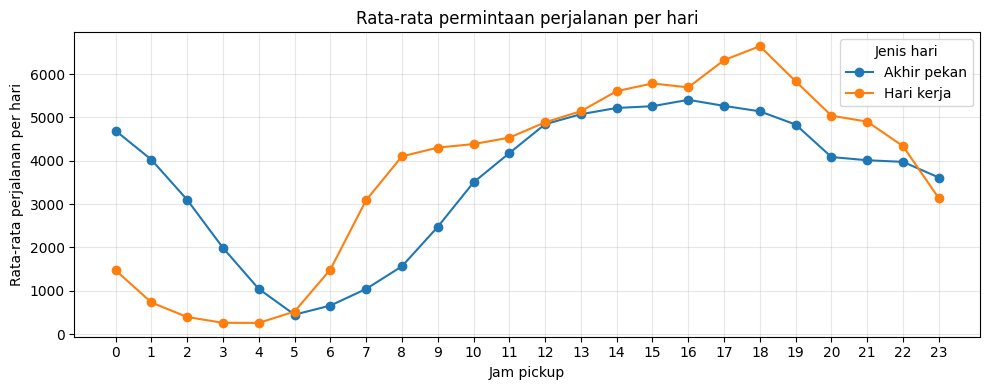

In [29]:
plot_jumlah = (ringkas
    .pivot(index="jam", columns="jenis_hari", values="rata_per_hari")
    .reindex(range(24)))
plot_jumlah.columns.name = "Jenis hari"

ax = plot_jumlah.plot(figsize=(10, 4), marker="o")
ax.set_title("Rata-rata permintaan perjalanan per hari")
ax.set_xlabel("Jam pickup")
ax.set_ylabel("Rata-rata perjalanan per hari")
ax.set_xticks(range(24))
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(
    f"{DIR_SIMPAN}/studi_kasus_permintaan_per_jam.png",
    dpi=150, bbox_inches="tight")
plt.show()

Grafik 2: rata-rata tarif per menit per jam menurut jenis hari.

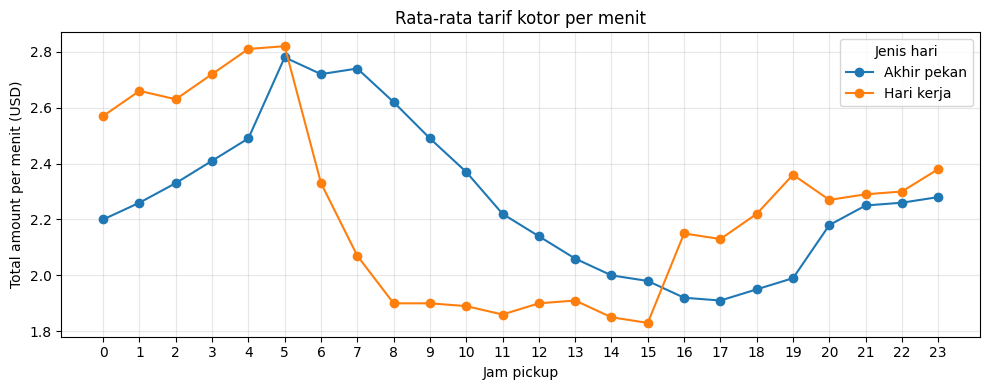

In [30]:
plot_tarif = (ringkas
    .pivot(index="jam", columns="jenis_hari", values="rata_tarif_per_menit")
    .reindex(range(24)))
plot_tarif.columns.name = "Jenis hari"

ax = plot_tarif.plot(figsize=(10, 4), marker="o")
ax.set_title("Rata-rata tarif kotor per menit")
ax.set_xlabel("Jam pickup")
ax.set_ylabel("Total amount per menit (USD)")
ax.set_xticks(range(24))
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(
    f"{DIR_SIMPAN}/studi_kasus_tarif_per_menit.png",
    dpi=150, bbox_inches="tight")
plt.show()

Keluaran untuk manajemen: tiga rekomendasi operasional.

Hasil verifikasi pada data bersih: permintaan tertinggi terjadi pada jam 18.00 (210.858 perjalanan) dan terendah pada jam 04.00 (16.618 perjalanan). Setelah dinormalisasi per hari, puncak hari kerja berada pada jam 18.00 (6.644,04 perjalanan/hari), sedangkan akhir pekan pada jam 16.00 (5.405,70 perjalanan/hari). Jam sibuk didefinisikan sebagai 15.00-18.00; rata-rata durasinya 15,76 menit dibanding 14,15 menit pada jam lain, sedangkan tarif kotor per menitnya 2,05 dibanding 2,14. Jadi, jam sibuk tidak lebih pendek dan tidak lebih menguntungkan per menit pada data ini.

In [31]:
rekomendasi = [
    (
        f"Prioritaskan penambahan armada mendekati jam {jam_tertinggi:02d}.00 "
        f"karena permintaan tertinggi mencapai "
        f"{int(baris_tertinggi['jumlah_perjalanan']):,} perjalanan; "
        "batasannya, dataset hanya satu file bulan Januari sehingga pola "
        "musiman belum terwakili."
    ),
    (
        f"Atur shift akhir pekan berbeda dengan puncak sekitar jam "
        f"{int(puncak_akhir_pekan['jam_puncak']):02d}.00 "
        f"({puncak_akhir_pekan['rata_perjalanan_per_hari_puncak']:,.0f} perjalanan/hari); "
        "batasannya, jumlah hari teramati terbatas sehingga pola ini perlu "
        "divalidasi pada beberapa bulan."
    ),
    (
        f"Jangan menjadikan jam sibuk sebagai indikator keuntungan tunggal "
        f"karena tarif kotor per menitnya {baris_sibuk['rata_tarif_per_menit']:.2f} "
        f"lebih rendah daripada {baris_lain['rata_tarif_per_menit']:.2f} "
        "pada jam lain; batasannya, total_amount belum dikurangi biaya "
        "operasional dan waktu tanpa penumpang."
    )
]

for nomor, kalimat in enumerate(rekomendasi, start=1):
    print(f"{nomor}. {kalimat}")

1. Prioritaskan penambahan armada mendekati jam 18.00 karena permintaan tertinggi mencapai 210,858 perjalanan; batasannya, dataset hanya satu file bulan Januari sehingga pola musiman belum terwakili.
2. Atur shift akhir pekan berbeda dengan puncak sekitar jam 16.00 (5,406 perjalanan/hari); batasannya, jumlah hari teramati terbatas sehingga pola ini perlu divalidasi pada beberapa bulan.
3. Jangan menjadikan jam sibuk sebagai indikator keuntungan tunggal karena tarif kotor per menitnya 2.05 lebih rendah daripada 2.14 pada jam lain; batasannya, total_amount belum dikurangi biaya operasional dan waktu tanpa penumpang.
